In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

In [2]:
def phi1(t,j):
    return t**(j-1)



In [3]:
def phi2(t,j):
    return (t-1990)**(j-1)

In [4]:
def phi3(t,j):
    return (t-1940)**(j-1)

In [5]:
def phi4(t,j):
    return ((t-1940)/40)**(j-1)

In [6]:
file = pd.read_csv("./lab3/USA_population.csv", delimiter=';').dropna()

In [33]:
years = np.astype(file.Rok.values_horner, np.float64)
populations = file.Populacja.values_horner



# a

In [42]:
j_s = np.array([i for i in range(1,10)])
years_column = years[:,np.newaxis]
functions = [phi1,phi2,phi3,phi4]


Vandermonds_matrixes = [fun(years_column,j_s) for fun in functions]

In [45]:
print(Vandermonds_matrixes)

[array([[1.00000000e+00, 1.90000000e+03, 3.61000000e+06, 6.85900000e+09,
        1.30321000e+13, 2.47609900e+16, 4.70458810e+19, 8.93871739e+22,
        1.69835630e+26],
       [1.00000000e+00, 1.91000000e+03, 3.64810000e+06, 6.96787100e+09,
        1.33086336e+13, 2.54194902e+16, 4.85512263e+19, 9.27328422e+22,
        1.77119729e+26],
       [1.00000000e+00, 1.92000000e+03, 3.68640000e+06, 7.07788800e+09,
        1.35895450e+13, 2.60919263e+16, 5.00964985e+19, 9.61852772e+22,
        1.84675732e+26],
       [1.00000000e+00, 1.93000000e+03, 3.72490000e+06, 7.18905700e+09,
        1.38748800e+13, 2.67785184e+16, 5.16825405e+19, 9.97473033e+22,
        1.92512295e+26],
       [1.00000000e+00, 1.94000000e+03, 3.76360000e+06, 7.30138400e+09,
        1.41646850e+13, 2.74794888e+16, 5.33102083e+19, 1.03421804e+23,
        2.00638300e+26],
       [1.00000000e+00, 1.95000000e+03, 3.80250000e+06, 7.41487500e+09,
        1.44590062e+13, 2.81950622e+16, 5.49803713e+19, 1.07211724e+23,
        2.

# b

In [46]:
conds = np.linalg.cond(Vandermonds_matrixes)

In [47]:
print(conds)

[3.98276624e+36 1.25021079e+17 9.31553605e+12 1.60544370e+03]


# c

In [48]:
best_conditioned_polynomial_basis = Vandermonds_matrixes[3]
coefficients = np.linalg.solve(best_conditioned_polynomial_basis,populations)

In [49]:
print(coefficients)

[ 1.32164569e+08  4.61307656e+07  1.02716315e+08  1.82527130e+08
 -3.74614715e+08 -3.42668456e+08  6.06291250e+08  1.89175576e+08
 -3.15180235e+08]


In [52]:
def horner(coefficients,x):
    reversed_coefficients = coefficients[::-1]
    result = reversed_coefficients[0]
    for a in reversed_coefficients[1::]:
        result = result*x + a
    return result

In [63]:
all_years = np.arange(1900,1991)
all_years_normalized = (all_years-1940)/40
values_horner = horner(coefficients, all_years_normalized)
#print(values_horner[:5])
#print(np.polyval(coefficients[::-1],all_years)[:5])

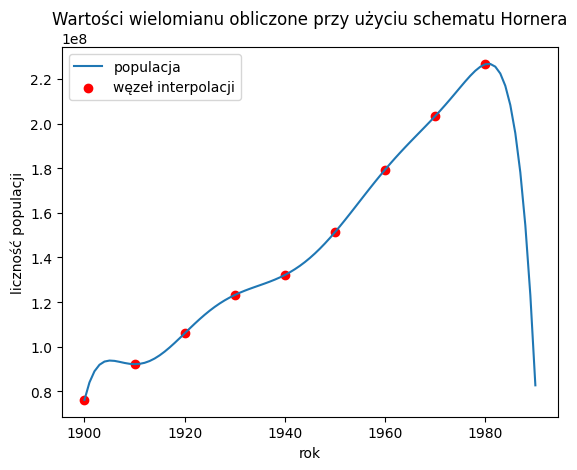

In [70]:
plt.plot(all_years, values_horner, label="populacja")
plt.scatter(years,populations,color="red",label="węzeł interpolacji")
plt.title("Wartości wielomianu obliczone przy użyciu schematu Hornera")
plt.xlabel("rok")
plt.ylabel("liczność populacji")
plt.legend()



# d

In [71]:
estimated_value = values_horner[-1]
true_value = 248_709_873
relative_error = abs(estimated_value-true_value)/true_value
print(relative_error)

0.6672864651416454


 # e

In [124]:
def create_lagrange_polynomial(nodes):
    result_functions = []

    for j in range(len(nodes)):
        l_j = lambda x, j_idx=j, all_nodes=nodes: np.prod([
            (x - n) / (all_nodes[j_idx] - n)
            for k, n in enumerate(all_nodes) if k != j_idx
        ],axis=0)
        result_functions.append(l_j)

    return result_functions


In [125]:
unique_polynomials = create_lagrange_polynomial(years)
lagrange_poly = lambda x: sum(y * L(x) for y, L in zip(populations, unique_polynomials))
values_lagrange = lagrange_poly(all_years)

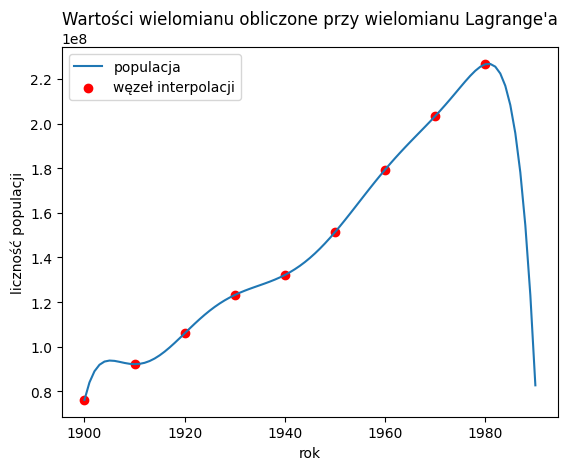

In [126]:
plt.clf()
plt.plot(all_years, values_lagrange, label="populacja")
plt.scatter(years,populations,color="red",label="węzeł interpolacji")
plt.title("Wartości wielomianu obliczone przy wielomianu Lagrange'a")
plt.xlabel("rok")
plt.ylabel("liczność populacji")
plt.legend()